# Analysation of Baseline Experiment Latency Data
In this notebook the result of the baseline latency experiments are analyzed

In [414]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [415]:
from utils import *
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Dict

## 1) Load Result Dataframe
This section loads the raw results from the file systems `../results/baseline_experiments` folder and extracts the metadata from the file names. The raw results are stored in a dictionary of dataframes, where the key is the subfolder name and filename stem (e.g. "zenbook/boolq_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_once-per-sec_2025-12-03T20-58-00") and the value is the corresponding dataframe. The metadata extracted from the file name is stored in a separate dictionary, where the key is the same as in the raw_dfs and the value is a dictionary containing the device, dataset, model, execution mode and frequency.

In [416]:
results_dir = Path('../results/baseline_experiments') # Define root results directory

raw_files = sorted(results_dir.glob('**/*raw*.csv')) # Find all files containing "raw" and ending with .csv in all subdirectories

In [417]:
# Filter out any files we don't need for baseline result analysis
raw_files = [f for f in raw_files if 'archive' not in str(f) and 'jseq' not in str(f).lower() and "desktop-cloud" not in str(f).lower() and
                        'extended' not in str(f).lower() and 'desktop-v2' not in str(f).lower() and 'exponential-arrival' not in str(f).lower()]

In [418]:
# Load all raw experiment files into a dictionary of dataframes
raw_dfs = {}
raw_meta = {}  # a dataframe to store the metadata of the experiment extracted from the file name

for file_path in raw_files:
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip() # Strip whitespace from column names

        # Create key: subfolder_name/filename_stem
        relative_path = file_path.relative_to(results_dir)
        key = str(relative_path.parent / relative_path.stem)
        raw_meta[key] = parse_experiment_string(key)
        raw_dfs[key] = df

        print(f"{relative_path} -> shape {df.shape}")
    except Exception as e:
        print(f"[!] Error loading {file_path.name}: {e}")

print(f"\nSUCCESS: Loaded {len(raw_dfs)} raw dataframes")

cloud/ag-news_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T18-36-02.csv -> shape (500, 22)
cloud/ag-news_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T12-19-04.csv -> shape (500, 22)
cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-04T09-33-25.csv -> shape (500, 22)
cloud/boolq_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-01-31T19-51-47.csv -> shape (500, 22)
cloud/lorem-ipsum_raw_experiment_meta-llama-llama-3-2_always_cloud_once-per-sec.csv -> shape (201, 22)
cloud/lorem-ipsum_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec.csv -> shape (202, 22)
cloud/spam_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T17-54-44.csv -> shape (500, 22)
cloud/spam_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T08-09-41.csv -> shape (500, 22)
desktop/ag-news_raw_experiment_Llama-3-2-1B-Instruct-ONNX_

## 2) Analysis of Latency per Model, Dataset and Device
This analysis is used to show the statistics of the latency results for the on device and cloud models of different device and dataset configurations. The resulting numbers are used for the final tables in the paper.

In [419]:
def analyze_latency_statistics_for_one_device(device_name: str, dataset_name: str, raw_dfs: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze latency statistics for a given device and dataset. Returns a DataFrame with the results and indexed by model name.

    The route parameter is used to specify whether to analyze the cloud or device results, since some experiments have both cloud and device results (e.g. the spam dataset on the zenbook has both cloud and device results, while the m2air only has device results).

    :param device_name: The name of the device to be processed (zenbook, m2air, m4pro, cloud, desktop)
    :param dataset_name: The name of the dataset to be processed (boolq, spam, ag_news, lorem-ipsum)
    :return:
    """

    # filter all the raw dataframes which contain device and dataset name in their key (e.g. 'cloud' for all datasets from the cloud and spam for all experiments on the spam dataset)
    subset_raw_df = {key: df for key, df in raw_dfs.items() if device_name in key and dataset_name in key}

    latency_stats = {}
    for key, df in subset_raw_df.items():
        if 'inference_time_ms' not in df.columns:
            continue

        series = df['inference_time_ms'].dropna()

        mean_latency = series.mean()
        median_latency = series.median()
        std_latency = series.std()
        q25 = series.quantile(0.25)
        q75 = series.quantile(0.75)
        iqr_latency = q75 - q25

        mean_accuracy = df['exact_match'].mean() if 'exact_match' in df.columns else None

        # extract information from metadata
        experiment_meta = raw_meta[key]

        # normalize model name of llama to match cloud and on-device version
        if 'llama' in experiment_meta['model'].lower():
            experiment_meta['model'] = 'Llama-3-2-1B-Instruct'

        # store the latency statistics in a dictionary, indexed by model name
        latency_stats[experiment_meta['model']] = {
            'model': experiment_meta['model'],
            'device': experiment_meta['device'],
            'dataset': experiment_meta['dataset'],
            'mean_latency_ms': round(mean_latency, 2),
            'std_latency_ms': round(std_latency, 2),
            'iqr_latency_ms': round(iqr_latency, 2),
            'mean_accuracy': round(mean_accuracy, 2),
            'median_latency_ms': round(median_latency, 2),
            'q25_latency_ms': round(q25, 2),
            'q75_latency_ms': round(q75, 2),
            'execution_mode: ': experiment_meta['execution_mode'],
            'key': key
        }

    # convert to a dataframe
    return pd.DataFrame.from_dict(latency_stats, orient='index')


### Show some results per device and dataset combination

In [420]:
# print the dataframe
analyze_latency_statistics_for_one_device('zenbook', 'boolq', raw_dfs=raw_dfs)

,model,device,dataset,mean_latency_ms,std_latency_ms,iqr_latency_ms,mean_accuracy,median_latency_ms,q25_latency_ms,q75_latency_ms,execution_mode:,key
Llama-3-2-1B-Instruct,Llama-3-2-1B-Instruct,zenbook,boolq,1773.50,708.28,513.75,0.59,1638.0,1436.50,1950.25,always-device,zenbook/boolq_raw_experiment_Llama-3-2-1B-Inst...
granite-4-0-350m-ONNX-web,granite-4-0-350m-ONNX-web,zenbook,boolq,738.51,285.38,423.00,0.50,695.0,508.75,931.75,always-device,zenbook/boolq_raw_experiment_granite-4-0-350m-...


In [421]:
analyze_latency_statistics_for_one_device('m2air', 'spam', raw_dfs=raw_dfs)

,model,device,dataset,mean_latency_ms,std_latency_ms,iqr_latency_ms,mean_accuracy,median_latency_ms,q25_latency_ms,q75_latency_ms,execution_mode:,key
Llama-3-2-1B-Instruct,Llama-3-2-1B-Instruct,m2air,spam,3309.95,5266.40,2293.00,0.45,1680.5,1067.0,3360.00,always-device,m2air/spam_raw_experiment_Llama-3-2-1B-Instruc...
granite-4-0-350m-ONNX-web,granite-4-0-350m-ONNX-web,m2air,spam,1277.56,2051.24,854.75,0.50,558.0,364.5,1219.25,always-device,m2air/spam_raw_experiment_granite-4-0-350m-ONN...


In [422]:
analyze_latency_statistics_for_one_device('m4pro', 'spam', raw_dfs=raw_dfs)

,model,device,dataset,mean_latency_ms,std_latency_ms,iqr_latency_ms,mean_accuracy,median_latency_ms,q25_latency_ms,q75_latency_ms,execution_mode:,key
Llama-3-2-1B-Instruct,Llama-3-2-1B-Instruct,m4pro,spam,779.98,813.29,538.25,0.46,490.0,340.75,879.00,always-device,m4pro/spam_raw_experiment_Llama-3-2-1B-Instruc...
granite-4-0-350m-ONNX-web,granite-4-0-350m-ONNX-web,m4pro,spam,417.17,502.44,256.25,0.50,250.0,176.00,432.25,always-device,m4pro/spam_raw_experiment_granite-4-0-350m-ONN...


In [423]:
analyze_latency_statistics_for_one_device('cloud', 'spam', raw_dfs=raw_dfs)

,model,device,dataset,mean_latency_ms,std_latency_ms,iqr_latency_ms,mean_accuracy,median_latency_ms,q25_latency_ms,q75_latency_ms,execution_mode:,key
Llama-3-2-1B-Instruct,Llama-3-2-1B-Instruct,cloud,spam,363.92,266.64,94.25,0.37,356.0,311.75,406.00,always-cloud,cloud/spam_raw_experiment_meta-llama-llama-3-2...
openai-gpt-4-1-mini,openai-gpt-4-1-mini,cloud,spam,659.36,277.78,123.25,0.97,588.0,544.00,667.25,always-cloud,cloud/spam_raw_experiment_openai-gpt-4-1-mini_...


### Prepare final results per dataset
This section prepares the final results per dataset by combining the results from all devices into a single dataframe. Those numbers are used for the final table in the paper and are indexed by device and model name to result in a plot per dataset.

In [424]:
def analyze_latency_statistics_per_dataset(dataset_name: str, raw_dfs: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze latency statistics for all device and model combinations for a given dataset.
    Returns a DataFrame with the results and indexed by device and the experiment name.

    :param dataset_name: The name of the dataset to be processed (boolq, spam, ag_news, lorem-ipsum)
    :return:
    """
    devices = ['zenbook', 'm2air', 'm4pro', 'cloud', 'desktop']
    all_stats = []

    for device in devices:
        stats_df = analyze_latency_statistics_for_one_device(device, dataset_name, raw_dfs=raw_dfs)
        stats_df['device'] = device
        all_stats.append(stats_df)

    dataset_results = pd.concat(all_stats)

    # set multi index for model and device
    dataset_results = dataset_results.set_index(['model', 'device']).sort_index()

    # sort results by device in order: zenbook, m2air, m4pro, cloud, desktop
    device_order = ['zenbook', 'm2air', 'm4pro', 'desktop', 'cloud']
    dataset_results = dataset_results.reindex(device_order, level='device')

    return dataset_results


In [425]:
boolq_results = analyze_latency_statistics_per_dataset('boolq', raw_dfs=raw_dfs)

# filter boolq results for only the models shown in the paper
boolq_results = boolq_results[boolq_results.index.get_level_values('model').isin(
    ['Llama-3-2-1B-Instruct', 'granite-4-0-350m-ONNX-web', 'openai-gpt-4-1-mini'])]
boolq_results

dataset  mean_latency_ms  std_latency_ms  \
model                     device                                             
Llama-3-2-1B-Instruct     zenbook   boolq          1773.50          708.28   
                          m2air     boolq           932.35          359.42   
                          m4pro     boolq           348.34           83.16   
                          desktop   boolq           194.63           79.79   
                          cloud     boolq           281.40          131.05   
granite-4-0-350m-ONNX-web zenbook   boolq           738.51          285.38   
                          m2air     boolq           388.06          113.08   
                          m4pro     boolq           175.61           44.62   
                          desktop   boolq           187.10           64.53   
openai-gpt-4-1-mini       cloud     boolq           654.36          398.34   

                                   iqr_latency_ms  mean_accuracy  \
model                     device                                   
Llama-3-2-1B-Instruct     zenbook          513.75           0.59   
                          m2air            342.50           0.62   
                          m4pro            102.25           0.54   
                          desktop           96.00           0.56   
                          cloud            218.00           0.55   
granite-4-0-350m-ONNX-web zenbook          423.00           0.50   
                          m2air            135.00           0.50   
                          m4pro             60.00           0.50   
                          desktop           80.25           0.50   
openai-gpt-4-1-mini       cloud            117.00           0.84   

                                   median_latency_ms  q25_latency_ms  \
model                     device                                       
Llama-3-2-1B-Instruct     zenbook             1638.0         1436.50   
                          m2air                856.0          717.00   
                          m4pro                317.0          288.75   
                          desktop              168.0          139.00   
                          cloud                293.0          171.00   
granite-4-0-350m-ONNX-web zenbook              695.0          508.75   
                          m2air                357.0          310.00   
                          m4pro                170.0          140.00   
                          desktop              190.0          143.75   
openai-gpt-4-1-mini       cloud                574.0          543.00   

                                   q75_latency_ms execution_mode:   \
model                     device                                     
Llama-3-2-1B-Instruct     zenbook         1950.25    always-device   
                          m2air           1059.50    always-device   
                          m4pro            391.00    always-device   
                          desktop          235.00    always-device   
                          cloud            389.00     always-cloud   
granite-4-0-350m-ONNX-web zenbook          931.75    always-device   
                          m2air            445.00    always-device   
                          m4pro            200.00    always-device   
                          desktop          224.00    always-device   
openai-gpt-4-1-mini       cloud            660.00     always-cloud   

                                                                                 key  
model                     device                                                      
Llama-3-2-1B-Instruct     zenbook  zenbook/boolq_raw_experiment_Llama-3-2-1B-Inst...  
                          m2air    m2air/boolq_raw_experiment_Llama-3-2-1B-Instru...  
                          m4pro    m4pro/boolq_raw_experiment_Llama-3-2-1B-Instru...  
                          desktop  desktop/boolq_raw_experiment_Llama-3-2-1B-Inst...  
                          cloud    cloud/boolq_raw_e

In [426]:
spam_results = analyze_latency_statistics_per_dataset('spam', raw_dfs=raw_dfs)
spam_results

dataset  mean_latency_ms  std_latency_ms  \
model                     device                                             
Llama-3-2-1B-Instruct     m2air      spam          3309.95         5266.40   
                          m4pro      spam           779.98          813.29   
                          desktop    spam           313.65          276.79   
                          cloud      spam           363.92          266.64   
granite-4-0-350m-ONNX-web zenbook    spam          2069.57         2924.85   
                          m2air      spam          1277.56         2051.24   
                          m4pro      spam           417.17          502.44   
                          desktop    spam           254.61          221.35   
openai-gpt-4-1-mini       cloud      spam           659.36          277.78   

                                   iqr_latency_ms  mean_accuracy  \
model                     device                                   
Llama-3-2-1B-Instruct     m2air           2293.00           0.45   
                          m4pro            538.25           0.46   
                          desktop          219.25           0.46   
                          cloud             94.25           0.37   
granite-4-0-350m-ONNX-web zenbook         1460.25           0.51   
                          m2air            854.75           0.50   
                          m4pro            256.25           0.50   
                          desktop          195.25           0.50   
openai-gpt-4-1-mini       cloud            123.25           0.97   

                                   median_latency_ms  q25_latency_ms  \
model                     device                                       
Llama-3-2-1B-Instruct     m2air               1680.5         1067.00   
                          m4pro                490.0          340.75   
                          desktop              224.5          154.75   
                          cloud                356.0          311.75   
granite-4-0-350m-ONNX-web zenbook             1115.5          636.00   
                          m2air                558.0          364.50   
                          m4pro                250.0          176.00   
                          desktop              187.5          116.00   
openai-gpt-4-1-mini       cloud                588.0          544.00   

                                   q75_latency_ms execution_mode:   \
model                     device                                     
Llama-3-2-1B-Instruct     m2air           3360.00    always-device   
                          m4pro            879.00    always-device   
                          desktop          374.00    always-device   
                          cloud            406.00     always-cloud   
granite-4-0-350m-ONNX-web zenbook         2096.25    always-device   
                          m2air           1219.25    always-device   
                          m4pro            432.25    always-device   
                          desktop          311.25    always-device   
openai-gpt-4-1-mini       cloud            667.25     always-cloud   

                                                                                 key  
model                     device                                                      
Llama-3-2-1B-Instruct     m2air    m2air/spam_raw_experiment_Llama-3-2-1B-Instruc...  
                          m4pro    m4pro/spam_raw_experiment_Llama-3-2-1B-Instruc...  
                          desktop  desktop/spam_raw_experiment_Llama-3-2-1B-Instr...  
                          cloud    cloud/spam_raw_experiment_meta-llama-llama-3-2...  
granite-4-0-350m-ONNX-web zenbook  zenbook/spam_raw_experiment_granite-4-0-350m-O...  
                          m2air    m2air/spam_raw_experiment_granite-4-0-350m-ONN...  
                          m4pro    m4pro/spam_raw_experiment_granite-4-0-350m-ONN...  
                          desktop  desktop/spam_raw_experiment_granite-4-0-350m

In [427]:
ag_news_results = analyze_latency_statistics_per_dataset('ag-news', raw_dfs=raw_dfs)
ag_news_results

dataset  mean_latency_ms  std_latency_ms  \
model                     device                                              
Llama-3-2-1B-Instruct     zenbook  ag-news          1529.07          227.18   
                          m2air    ag-news           328.40           30.21   
                          m4pro    ag-news           307.61           29.21   
                          desktop  ag-news           187.75           73.18   
                          cloud    ag-news           347.08          143.95   
granite-4-0-350m-ONNX-web zenbook  ag-news           776.32          249.12   
                          m2air    ag-news           327.89           30.89   
                          m4pro    ag-news           154.22           14.73   
                          desktop  ag-news           179.01           57.98   
openai-gpt-4-1-mini       cloud    ag-news           631.32          253.16   

                                   iqr_latency_ms  mean_accuracy  \
model                     device                                   
Llama-3-2-1B-Instruct     zenbook          212.25           0.28   
                          m2air             38.00           0.22   
                          m4pro             24.00           0.27   
                          desktop           69.50           0.28   
                          cloud            102.25           0.26   
granite-4-0-350m-ONNX-web zenbook          494.25           0.22   
                          m2air             39.00           0.22   
                          m4pro             19.00           0.22   
                          desktop           72.25           0.22   
openai-gpt-4-1-mini       cloud            123.25           0.86   

                                   median_latency_ms  q25_latency_ms  \
model                     device                                       
Llama-3-2-1B-Instruct     zenbook             1506.5         1396.75   
                          m2air                331.5          307.00   
                          m4pro                306.0          287.00   
                          desktop              165.0          138.75   
                          cloud                333.0          298.00   
granite-4-0-350m-ONNX-web zenbook              868.5          503.75   
                          m2air                332.5          305.00   
                          m4pro                156.0          143.00   
                          desktop              189.0          132.75   
openai-gpt-4-1-mini       cloud                573.0          525.75   

                                   q75_latency_ms execution_mode:   \
model                     device                                     
Llama-3-2-1B-Instruct     zenbook         1609.00    always-device   
                          m2air            345.00    always-device   
                          m4pro            311.00    always-device   
                          desktop          208.25    always-device   
                          cloud            400.25     always-cloud   
granite-4-0-350m-ONNX-web zenbook          998.00    always-device   
                          m2air            344.00    always-device   
                          m4pro            162.00    always-device   
                          desktop          205.00    always-device   
openai-gpt-4-1-mini       cloud            649.00     always-cloud   

                                                                                 key  
model                     device                                                      
Llama-3-2-1B-Instruct     zenbook  zenbook/ag-news_raw_experiment_Llama-3-2-1B-In...  
                          m2air    m2air/ag-news_raw_experiment_Llama-3-2-1B-Inst...  
                          m4pro    m4pro/ag-news_raw_experiment_Llama-3-2-1B-Inst...  
                          desktop  desktop/ag-news_raw_experiment_Llama-3-2-1B-In...  
                          cloud    cloud/

In [428]:
lorem_ipsum_results = analyze_latency_statistics_per_dataset('lorem-ipsum', raw_dfs=raw_dfs)
lorem_ipsum_results

dataset  mean_latency_ms  \
model                     device                                  
Llama-3-2-1B-Instruct     m2air    lorem-ipsum         27368.03   
                          m4pro    lorem-ipsum          5771.26   
                          desktop  lorem-ipsum          1529.79   
                          cloud    lorem-ipsum           901.22   
experiment                zenbook  lorem-ipsum         10827.04   
granite-4-0-350m-ONNX-web m2air    lorem-ipsum         16398.34   
                          m4pro    lorem-ipsum          4237.88   
                          desktop  lorem-ipsum          1770.93   
openai-gpt-4-1-mini       cloud    lorem-ipsum           698.38   

                                   std_latency_ms  iqr_latency_ms  \
model                     device                                    
Llama-3-2-1B-Instruct     m2air          24865.75        35071.75   
                          m4pro           4447.45         7204.50   
                          desktop          956.29         1517.75   
                          cloud            445.99          669.00   
experiment                zenbook         9248.08        16271.25   
granite-4-0-350m-ONNX-web m2air          14635.31        24376.00   
                          m4pro           3541.52         5863.00   
                          desktop         1383.45         2041.00   
openai-gpt-4-1-mini       cloud            316.80          160.50   

                                   mean_accuracy  median_latency_ms  \
model                     device                                      
Llama-3-2-1B-Instruct     m2air             0.00            21310.0   
                          m4pro             0.00             4777.0   
                          desktop           0.00             1561.0   
                          cloud             0.00              838.0   
experiment                zenbook           0.04             7985.0   
granite-4-0-350m-ONNX-web m2air             0.02            11609.0   
                          m4pro             0.02             3316.0   
                          desktop           0.02             1472.0   
openai-gpt-4-1-mini       cloud             0.79              616.5   

                                   q25_latency_ms  q75_latency_ms  \
model                     device                                    
Llama-3-2-1B-Instruct     m2air           5976.25        41048.00   
                          m4pro           1872.50         9077.00   
                          desktop          623.75         2141.50   
                          cloud            533.00         1202.00   
experiment                zenbook         2415.50        18686.75   
granite-4-0-350m-ONNX-web m2air           3392.00        27768.00   
                          m4pro           1030.00         6893.00   
                          desktop          546.00         2587.00   
openai-gpt-4-1-mini       cloud            549.00          709.50   

                                                   execution_mode:   \
model                     device                                      
Llama-3-2-1B-Instruct     m2air                       always-device   
                          m4pro                       always-device   
                          desktop                     always-device   
                          cloud                        always-cloud   
experiment                zenbook  granite-4-0-350m-ONNX-web-always   
granite-4-0-350m-ONNX-web m2air                       always-device   
                          m4pro                       always-device   
                          desktop                     always-device   
openai-gpt-4-1-mini       cloud                        always-cloud   

                                                                                 key  
model                     device                                                      
Llama-3-2-1B-Instruct     m2air    m2air/lo

## 3) Prompt Characters vs. Latency Analysis
This analysis is used to show the correlation between input size (in tokens) and latency for different models and devices.

In [429]:
def get_datasets_for_model_and_device(model_name: str, device_name: str) -> Dict[str, pd.DataFrame]:
    """
    Get the raw dataframes for a given model and device combination.

    :param model_name: The name of the model to be processed (e.g. Llama-3-2-1B-Instruct)
    :param device_name: The name of the device to be processed (zenbook, m2air, m4pro, cloud, desktop)
    :return: A dictionary with dataset names as keys and corresponding dataframes as values.
    """
    SORT_ORDER = ['boolq', 'spam', 'ag-news', 'lorem-ipsum']
    DEVICE_NAME_MAP = {
        'zenbook': 'Asus Zenbook',
        'm2air': 'Macbook Air (M2)',
        'm4pro': 'Macbook Pro (M4 Pro)',
        'desktop': 'Desktop (RTX 4090)',
        'cloud': 'Cloud (OpenRouter)'
    }

    selected_dfs = {key: df for key, df in raw_dfs.items() if
                    device_name.lower() in key.lower() and model_name.lower() in key.lower()}

    def sort_key_logic(key):
            dataset_name = raw_meta[key]['dataset'].lower()
            if dataset_name in SORT_ORDER:
                return SORT_ORDER.index(dataset_name)
            else:
                return len(SORT_ORDER)  # Put unknown datasets at the end

    sorted_keys = sorted(selected_dfs.keys(), key=sort_key_logic)

    labels = []
    # extract the model names from the metadata and print them
    for key in sorted_keys:
        meta = raw_meta[key]
        labels.append(f"{meta['dataset']}")

    device_name_mapped = DEVICE_NAME_MAP.get(device_name.lower())

    plot_name = f"{model_name.title()} on {device_name_mapped}"

    # return a object with the dataframes and the labels for the plot
    return {
        "dataframes": [df for df in selected_dfs.values()],
        "labels": labels,
        "plot_name": plot_name
    }

In [430]:
def transform_experiment_data_for_plot(experiment_data_per_dataset):
    datasets = []
    labels = []
    plot_names = []

    for data in experiment_data_per_dataset:
        datasets.append(data['dataframes'])
        labels.append(data['labels'])
        plot_names.append(data['plot_name'])

    return datasets, labels, plot_names

### Show the correlation between input size and latency for the Llama model on different devices
Let's analyze the correlation between input size (in characters) and latency for the Llama model on different devices. We will extract the relevant dataframes for each device, transform the data for plotting, and then create a plot to visualize the relationship between input size and latency.

In [431]:
experiment_data_per_dataset_llama = [
    #get_datasets_for_model_and_device('llama', 'zenbook'),
    get_datasets_for_model_and_device('llama', 'm2air'),
    get_datasets_for_model_and_device('llama', 'm4pro'),
    get_datasets_for_model_and_device('llama', 'desktop'),
    get_datasets_for_model_and_device('llama', 'cloud')
]

In [432]:
llama_datasets, llama_labels, llama_plot_names = transform_experiment_data_for_plot(experiment_data_per_dataset_llama)

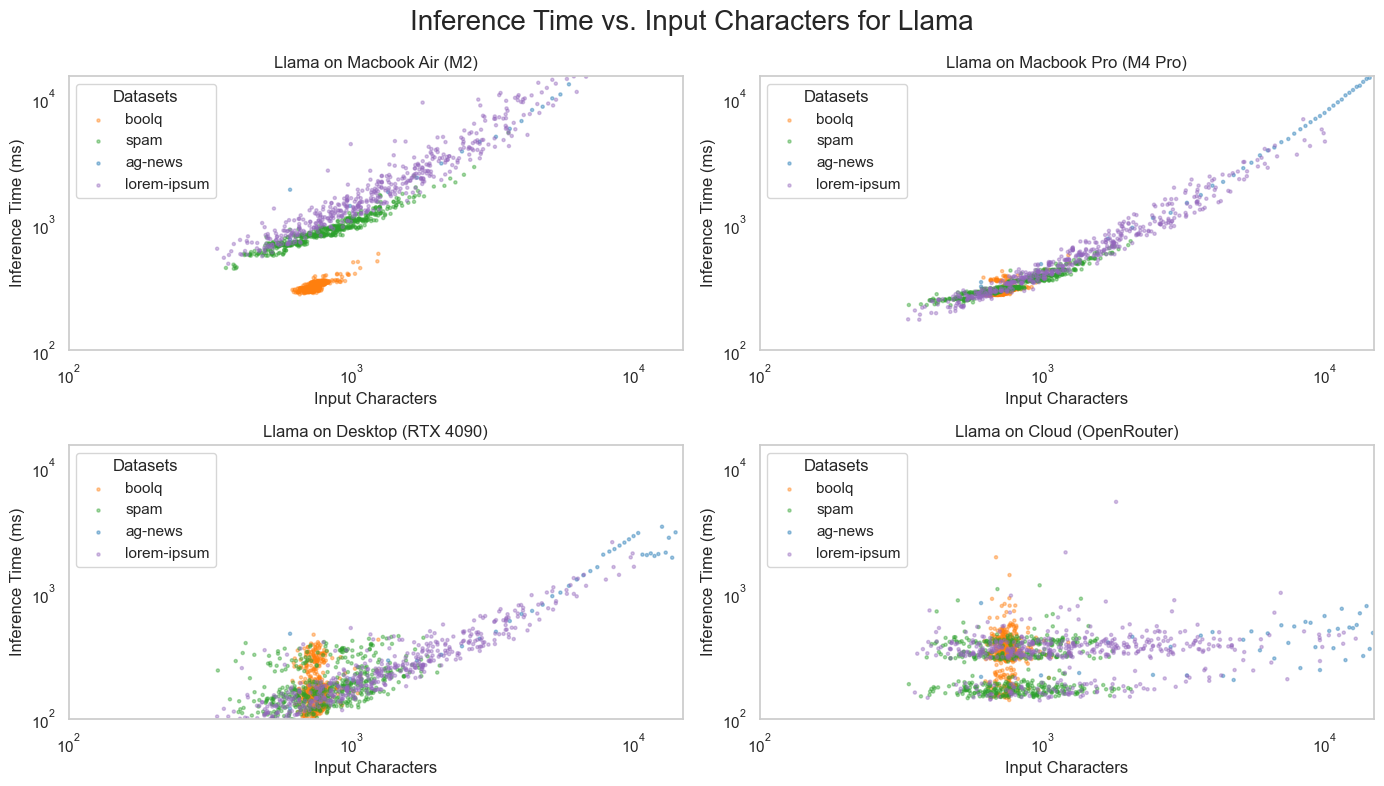

In [433]:
# plot inference vs input character amount
plot_characters_vs_inference_time(llama_datasets, llama_labels, llama_plot_names, model="Llama")

### Show the correlation between input size and latency for the Granit model on different devices
To generalize further, we analyze also the correlation for a second on-device model, the Granite model, on different devices.

In [434]:
experiment_data_per_dataset_granit = [
    get_datasets_for_model_and_device('granite', 'zenbook'),
    get_datasets_for_model_and_device('granite', 'm2air'),
    get_datasets_for_model_and_device('granite', 'm4pro'),
    get_datasets_for_model_and_device('granite', 'desktop')
]

In [435]:
granite_datasets, granite_labels, granite_plot_names = transform_experiment_data_for_plot(experiment_data_per_dataset_granit)

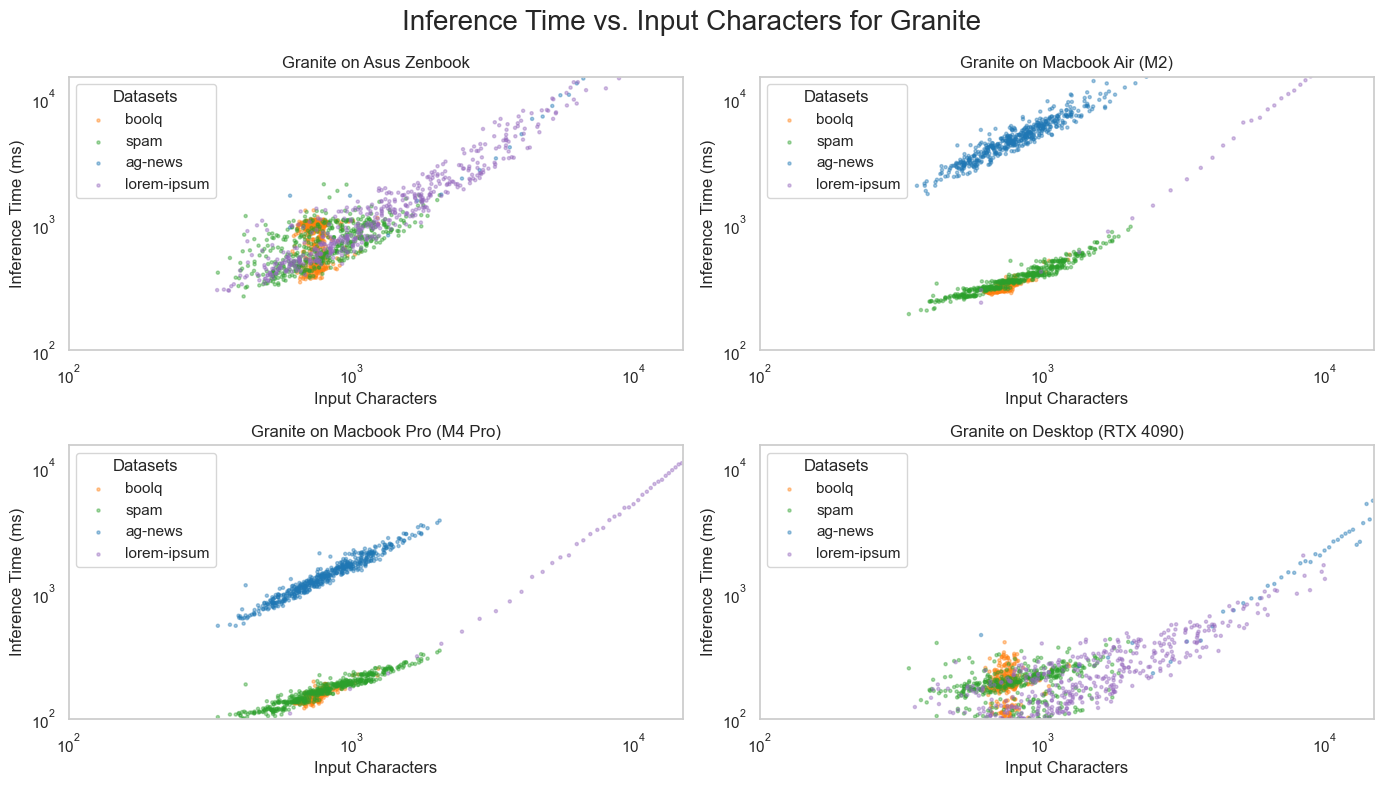

In [436]:
# plot inference vs input character amount
plot_characters_vs_inference_time(granite_datasets, llama_labels, granite_plot_names, model="Granite")

## 4) Dataset Distribution Analysis
Finally, we want to analyze the distribution of input sizes (in characters) for the different datasets to understand how the input size varies across datasets and how it might affect latency.

Remark:
Since we run all the analysis on the first 500 samples of each dataset, we can just analyze the distribution for one experiment per dataset and get the distribution of this dataset.

In [437]:
# extract for each dataset one experiment data
boolq_experiment_data = experiment_data_per_dataset_granit[0]['dataframes'][1]['number_of_characters']
spam_experiment_data = experiment_data_per_dataset_granit[0]['dataframes'][3]['number_of_characters']
ag_news_experiment_data = experiment_data_per_dataset_granit[0]['dataframes'][0]['number_of_characters']
lorem_ipsum_experiment_data =  experiment_data_per_dataset_granit[0]['dataframes'][2]['number_of_characters']

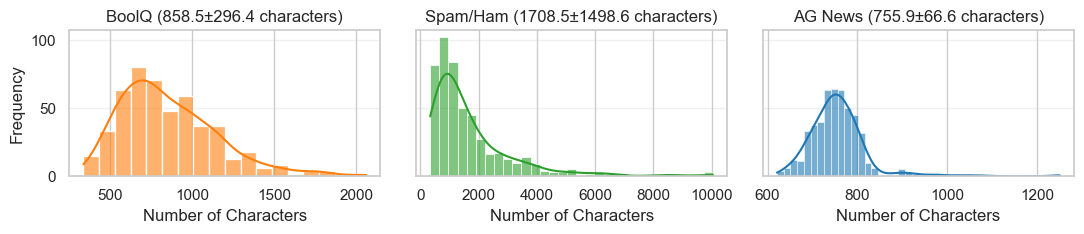

In [438]:
# pplot the distribution of characters for the three datasets
plot_input_character_distribution([boolq_experiment_data, spam_experiment_data, ag_news_experiment_data], ['BoolQ (858.5±296.4 characters)', 'Spam/Ham (1708.5±1498.6 characters)', 'AG News (755.9±66.6 characters)'])